<a href="https://colab.research.google.com/github/nesishaji/DL-ML-Projects/blob/main/Cervical_Cancer/FinalProject5_CervicalCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction

Cervical cancer is one of the most common and life-threatening diseases affecting women worldwide. Early detection and accurate diagnosis are essential for improving survival rates and reducing the risk of severe complications. However, traditional diagnostic methods often require extensive medical testing, expert analysis, and significant time, which may delay treatment. With the rapid growth of healthcare data and advancements in Artificial Intelligence, Machine Learning and Deep Learning techniques have become powerful tools for predicting and detecting cervical cancer more efficiently.

This project focuses on the prediction of cervical cancer using a large dataset containing 100,000 records and 8 important medical and lifestyle-related features. The dataset includes factors such as age, smoking habits, number of pregnancies, sexually transmitted diseases (STDs), hormonal contraceptive usage, age at first sexual intercourse, and number of sexual partners. These features play a significant role in identifying the risk factors associated with cervical cancer.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the Cervical Cancer dataset

df=pd.read_csv('/content/cervical_cancer_dataset_100k.csv')
df.head()

,Age,BMI,Smoking_Years,Alcohol_Consumption_Per_Week,HPV_Infection,Multiple_Partners,Early_Pregnancy,Contraceptive_Use_Years,STD_History,Family_History_Cancer,Pap_Smear_Result,Cervical_Cancer
0,56,27.0,22,8,0,6,1,1,0,0,Normal,0
1,69,34.7,7,0,0,8,0,15,0,1,Abnormal,1
2,46,23.4,17,10,1,8,0,14,0,0,Normal,1
3,32,22.9,13,10,0,0,0,3,0,1,Normal,0
4,60,25.5,2,3,0,2,1,1,0,0,Normal,0


In [ ]:
df.tail()

,Age,BMI,Smoking_Years,Alcohol_Consumption_Per_Week,HPV_Infection,Multiple_Partners,Early_Pregnancy,Contraceptive_Use_Years,STD_History,Family_History_Cancer,Pap_Smear_Result,Cervical_Cancer
99995,30,26.7,23,3,0,7,0,17,0,0,Normal,0
99996,53,18.6,17,8,0,1,0,19,0,0,Normal,0
99997,33,24.6,16,7,0,7,0,7,1,0,Normal,0
99998,57,29.2,8,6,0,9,1,9,0,0,Normal,0
99999,20,33.4,22,4,0,5,0,9,0,0,Normal,0


## **2 .Understand the Data Types and Summary**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           100000 non-null  int64  
 1   BMI                           100000 non-null  float64
 2   Smoking_Years                 100000 non-null  int64  
 3   Alcohol_Consumption_Per_Week  100000 non-null  int64  
 4   HPV_Infection                 100000 non-null  int64  
 5   Multiple_Partners             100000 non-null  int64  
 6   Early_Pregnancy               100000 non-null  int64  
 7   Contraceptive_Use_Years       100000 non-null  int64  
 8   STD_History                   100000 non-null  int64  
 9   Family_History_Cancer         100000 non-null  int64  
 10  Pap_Smear_Result              100000 non-null  object 
 11  Cervical_Cancer               100000 non-null  int64  
dtypes: float64(1), int64(10), object(1)
memory us

In [ ]:
df.shape

(100000, 12)

## **3. Data cleaning**

**1. Checking null values**

In [ ]:
df.isnull().sum()

,0
Age,0
BMI,0
Smoking_Years,0
Alcohol_Consumption_Per_Week,0
HPV_Infection,0
Multiple_Partners,0
Early_Pregnancy,0
Contraceptive_Use_Years,0
STD_History,0
Family_History_Cancer,0


**2. Cheking  if in this dataset exists duplicates or not**

In [ ]:
df.duplicated().sum()

np.int64(0)

we can use **unique()** to find **distinct** values in a object data column and **value_counts()** to see the **frequency of each unique value**.

In [ ]:
print (df['Pap_Smear_Result'].unique())

['Normal' 'Abnormal']


**3. Convert all object data to numerical**

In [ ]:
# Converting all the nominal datas to numerical values using labelencoder class

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
df["Pap_Smear_Result"]=le.fit_transform(df["Pap_Smear_Result"])

In [ ]:
df.head()

,Age,BMI,Smoking_Years,Alcohol_Consumption_Per_Week,HPV_Infection,Multiple_Partners,Early_Pregnancy,Contraceptive_Use_Years,STD_History,Family_History_Cancer,Pap_Smear_Result,Cervical_Cancer
0,56,27.0,22,8,0,6,1,1,0,0,1,0
1,69,34.7,7,0,0,8,0,15,0,1,0,1
2,46,23.4,17,10,1,8,0,14,0,0,1,1
3,32,22.9,13,10,0,0,0,3,0,1,1,0
4,60,25.5,2,3,0,2,1,1,0,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           100000 non-null  int64  
 1   BMI                           100000 non-null  float64
 2   Smoking_Years                 100000 non-null  int64  
 3   Alcohol_Consumption_Per_Week  100000 non-null  int64  
 4   HPV_Infection                 100000 non-null  int64  
 5   Multiple_Partners             100000 non-null  int64  
 6   Early_Pregnancy               100000 non-null  int64  
 7   Contraceptive_Use_Years       100000 non-null  int64  
 8   STD_History                   100000 non-null  int64  
 9   Family_History_Cancer         100000 non-null  int64  
 10  Pap_Smear_Result              100000 non-null  int64  
 11  Cervical_Cancer               100000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 9.2 MB

## **Visualization**

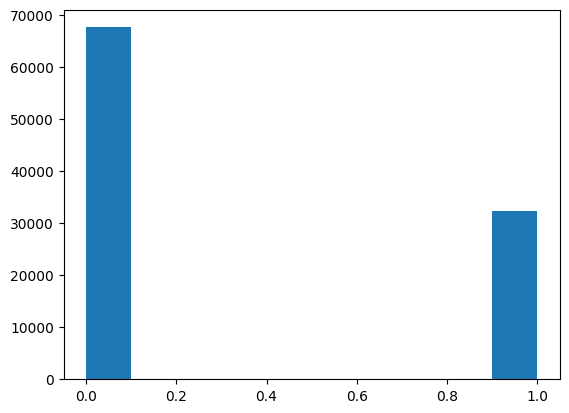

In [ ]:
plt.hist(df["Cervical_Cancer"])
plt.show()

<Axes: >

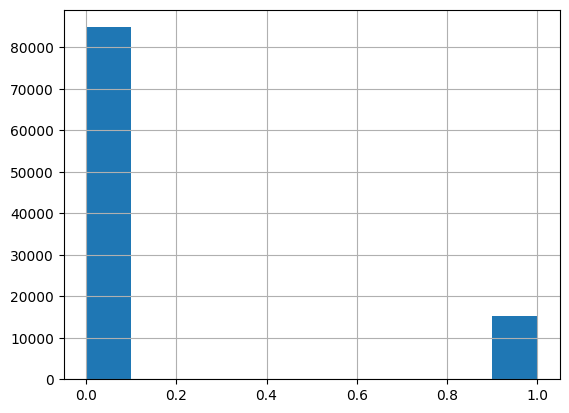

In [ ]:
df["Family_History_Cancer"].hist()

<Axes: >

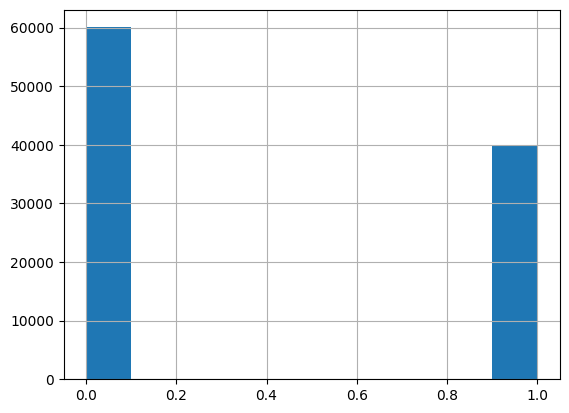

In [ ]:
df["Early_Pregnancy"].hist()

<Axes: >

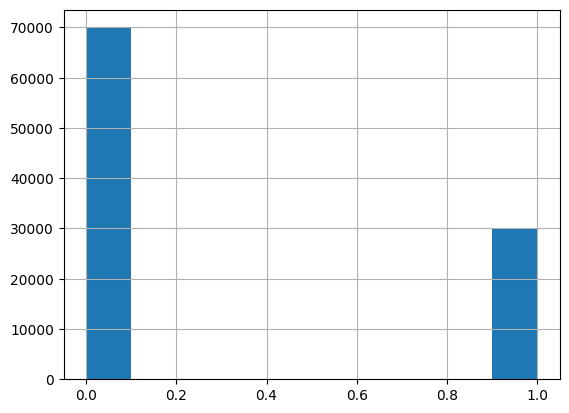

In [ ]:
df["HPV_Infection"].hist()

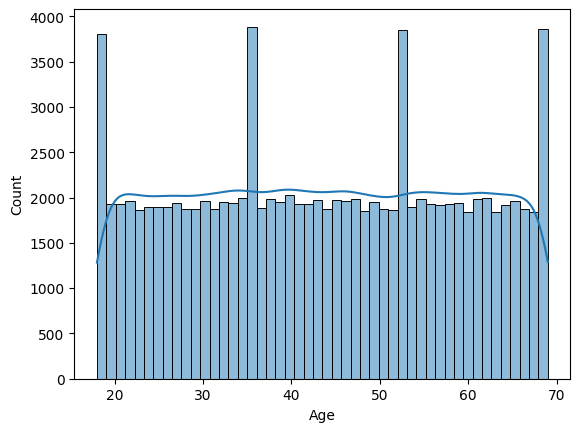

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.show()

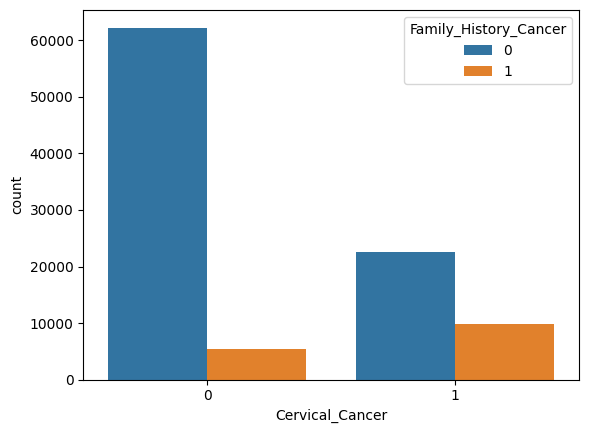

In [ ]:
sns.countplot(data=df, x='Cervical_Cancer', hue='Family_History_Cancer')
plt.show()

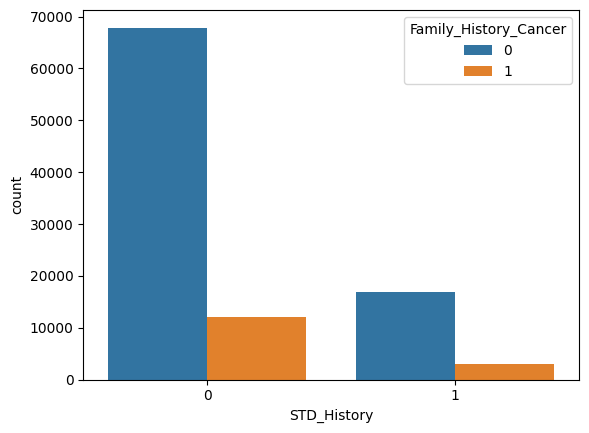

In [ ]:
sns.countplot(data=df, x='STD_History', hue='Family_History_Cancer')
plt.show()

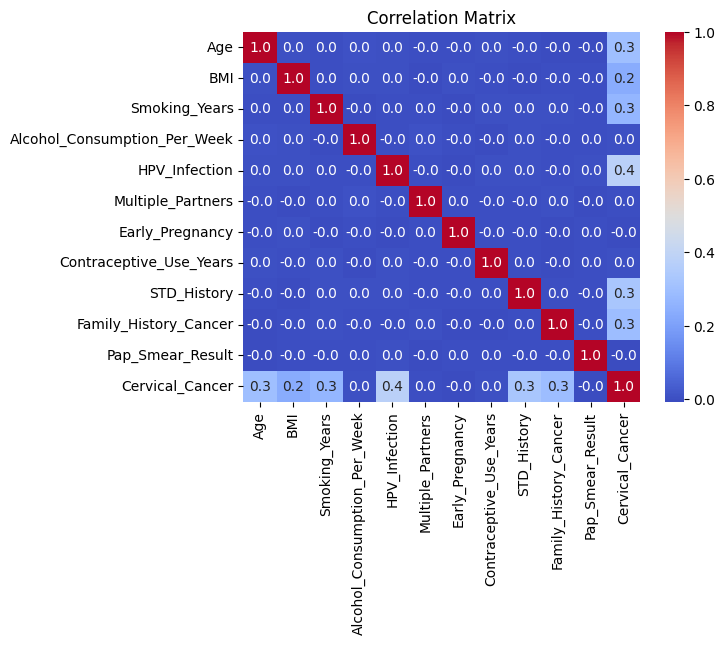

In [ ]:
# Correlation matrix
corr_matrix = df.corr()

# Heatmap of correlation matrix
sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm') # 0.01f should be given for float values, d for integers
plt.title('Correlation Matrix')
plt.show()

### check : Collinearity, multicollinearity

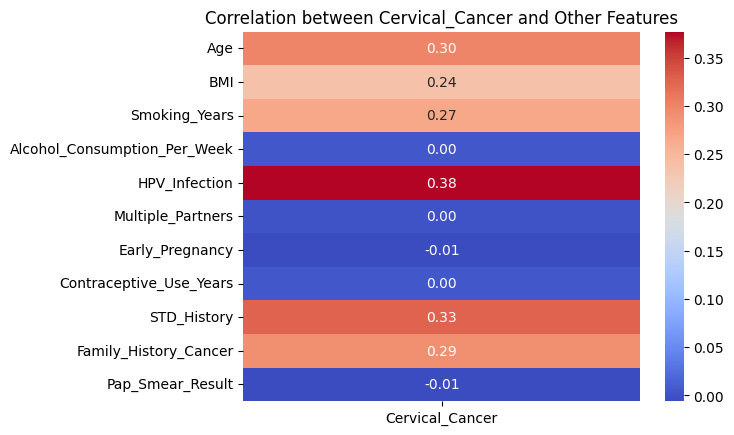

In [ ]:
# Calculate the correlation between 'Cervical_Cancer' and all other columns
Cervical_Cancer_corr = df.corr()['Cervical_Cancer']
# Remove the correlation of 'Cervical_Cancer'with itself (which is always 1)
Cervical_Cancer = Cervical_Cancer_corr.drop('Cervical_Cancer')
# Create a heatmap to visualize the correlations
sns.heatmap(Cervical_Cancer.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})  # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between Cervical_Cancer and Other Features')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           100000 non-null  int64  
 1   BMI                           100000 non-null  float64
 2   Smoking_Years                 100000 non-null  int64  
 3   Alcohol_Consumption_Per_Week  100000 non-null  int64  
 4   HPV_Infection                 100000 non-null  int64  
 5   Multiple_Partners             100000 non-null  int64  
 6   Early_Pregnancy               100000 non-null  int64  
 7   Contraceptive_Use_Years       100000 non-null  int64  
 8   STD_History                   100000 non-null  int64  
 9   Family_History_Cancer         100000 non-null  int64  
 10  Pap_Smear_Result              100000 non-null  int64  
 11  Cervical_Cancer               100000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 9.2 MB

###  **Now remove less correlated**

In [ ]:
df.drop(["Alcohol_Consumption_Per_Week", "Multiple_Partners", "Early_Pregnancy", 'Contraceptive_Use_Years', "Pap_Smear_Result"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Age                    100000 non-null  int64  
 1   BMI                    100000 non-null  float64
 2   Smoking_Years          100000 non-null  int64  
 3   HPV_Infection          100000 non-null  int64  
 4   STD_History            100000 non-null  int64  
 5   Family_History_Cancer  100000 non-null  int64  
 6   Cervical_Cancer        100000 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 5.3 MB


In [ ]:
df.shape

(100000, 7)

# After **EDA** we can predict

## Use LogisticRegression model if our dataset is classification (means discrete)  & if our dataset is regression (means continuous) use LinearRegression

## 1. LogisticRegression

use logisticRegression because our dataset is classification

In [ ]:
# use logisticRegression because our dataset is classification

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas

X = df[['Age','BMI','Smoking_Years',"HPV_Infection",'STD_History','Family_History_Cancer']]  # Features
y = df['Cervical_Cancer']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # You can adjust the test_size and random_state


# Train a baseline logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.90


## 2. KFOLD

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [ ]:
# Split features and target
X = df.drop('Cervical_Cancer', axis=1)
y = df['Cervical_Cancer']

# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()

# Track best fold data
best_accuracy = 0
best_fold = -1

# Save best fold's data
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred

# Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.8975
Fold 2 Accuracy: 0.90145
Fold 3 Accuracy: 0.89615
Fold 4 Accuracy: 0.8982
Fold 5 Accuracy: 0.89265

 Best Fold: 2 with Accuracy: 0.90145


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.90145

## 3. Decision Tree Algorithm

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas


X = df[['Age','BMI','Smoking_Years',"HPV_Infection",'STD_History','Family_History_Cancer']]  # Features
y = df['Cervical_Cancer']  # Target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # You can adjust the test_size and random_state



# Train DecisionTree Classifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


## 4. Support Vector Machine(SVM)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import pandas as pd

In [ ]:
X = df[['Age','BMI','Smoking_Years',"HPV_Infection",'STD_History','Family_History_Cancer']]  # Features
y = df['Cervical_Cancer']  # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',LinearSVC())
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f'Linear SVC Pipeline accuracy: {accuracy:.2f}')

Linear SVC Pipeline accuracy: 0.90


## 5. Random Forest Classifier

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

Using Random Forest Classifier

In [ ]:
X = df[['Age','BMI','Smoking_Years',"HPV_Infection",'STD_History','Family_History_Cancer']]  # Features
y = df['Cervical_Cancer']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict and evaluate the model

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


##**6. XG Boost**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [ ]:
# Features and target
X = df[['Age','BMI','Smoking_Years',"HPV_Infection",'STD_History','Family_History_Cancer']]  # Features
y = df['Cervical_Cancer']  # Target variable

model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predictions

y_pred = model.predict(X_test)

# Evaluation

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


## 7. Ada Boost Classifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Features and target
X = df[['Age','BMI','Smoking_Years',"HPV_Infection",'STD_History','Family_History_Cancer']]  # Features
y = df['Cervical_Cancer']  # Target variable

Train AdaBoost model

In [ ]:
model = AdaBoostClassifier()

model.fit(X_train, y_train)

AdaBoostClassifier()

In [ ]:
# Predictions

y_pred = model.predict(X_test)

# Evaluation

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


##  8. Deep Learning

Artificial Neural Networks (ANN)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Features and target
X = df[['Age','BMI','Smoking_Years',"HPV_Infection",'STD_History','Family_History_Cancer']]  # Features
y = df['Cervical_Cancer']  # Target variable

In [ ]:
# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(6,), activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))               # Hidden Layer 2
model.add(Dense(1, activation='sigmoid'))             # Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8453 - loss: 0.3764
Epoch 2/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9275 - loss: 0.1783
Epoch 3/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9463 - loss: 0.1296
Epoch 4/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9545 - loss: 0.1084
Epoch 5/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9585 - loss: 0.0992
Epoch 6/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9601 - loss: 0.0933
Epoch 7/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9614 - loss: 0.0906
Epoch 8/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9638 - loss: 0.0836
Epoch 9/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9655 - loss: 0.0807
Epoch 10/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9686 - loss: 0.0743


In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9696 - loss: 0.0672
Model Accuracy: 96.96%


# Conclusion

The Cervical Cancer Prediction project was successfully implemented using multiple machine learning and deep learning techniques. Different algorithms such as Logistic Regression, K-Fold Cross Validation, Decision Tree, SVM, Random Forest Classifier etc on Machine Learning and Artificial Neural Network - ANN in Deep Learning were applied to analyze and predict the possibility of cervical cancer.

The Deep Learning model outperformed other techniques because it was able to learn complex hidden patterns and relationships among the medical attributes more effectively. Features such as HPV infection, smoking years, STD history, family history of cancer etc contributed significantly to the prediction process.